In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    CVA_EM_4_COLOUR,
    CVA_EM_4_PATH,
    DATA_DIR,
    ERA_EM_PATH,
    ERA_EM_2_PATH,
    ERA_EM_4_PATH,
    ERA_EM_6_PATH,
    ERA_EM_PATHS,
    ERA_EM_COLOURS,
    FIGURES_PATH,
    LATENT_DIMS,
    N_BURNIN,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_MARKOV,
    RANDOM_SEED,
)
from id import NOTEBOOK_GITHUB_URL, fit_cva_em, fit_era_em, make_id_figure
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
ERA_DRIVE_SEED = 9      # RNG seed for ERA OLS input sequence
EM_SEED        = 2      # Brain seed for ERA+EM / CVA+EM time series
EM_DRIVE_SEED  = 42     # RNG seed for ERA+EM / CVA+EM random drive

N_SAMPLES   = 5000      # timesteps for training
HORIZON     = 30        # CVA+EM block-Hankel horizon
MAX_EM_ITER = 200
EM_TOL      = 1e-6

# Set this after inspecting freq_map and bode for n_x = 2, 4, 6.
# The chosen ERA+EM model is also saved to ERA_EM_PATH for downstream use.
CHOSEN_LATENT_DIM = 4

In [3]:
# ── derived: Brain dimensions ──────────────────────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b

print(f"n_u = {P_DIM}")
print(f"n_y = {Q_DIM}")
print(f"Fitting ERA+EM for n_x in {LATENT_DIMS}")

n_u = 2
n_y = 16
Fitting ERA+EM for n_x in [2, 4, 6]


In [4]:
# ── simulation: fit ERA+EM for each latent dimension, then CVA+EM at n_x=4 ────
# This cell is expensive (~4 EM runs). Expect several minutes.
ESTIMATES: dict[int, SystemEstimate] = {}

for n_x, colour in zip(LATENT_DIMS, ERA_EM_COLOURS):
    print(f"\n=== ERA+EM  n_x = {n_x} ===")
    est, logliks = fit_era_em(
        era_seed=RANDOM_SEED,
        era_drive_seed=ERA_DRIVE_SEED,
        n_u=P_DIM,
        n_y=Q_DIM,
        n_latent=n_x,
        n_markov=N_MARKOV,
        n_hankel_rows=N_HANKEL_ROWS,
        n_hankel_cols=N_HANKEL_COLS,
        em_seed=EM_SEED,
        em_drive_seed=EM_DRIVE_SEED,
        n_samples=N_SAMPLES,
        n_burnin=N_BURNIN,
        max_em_iter=MAX_EM_ITER,
        em_tol=EM_TOL,
        colour=colour,
    )
    est = SystemEstimate(
        name=f"era_em_{n_x}",
        label=rf"ERA+EM $n_x={n_x}$",
        colour=colour,
        A=est.A, B=est.B, C=est.C, Q=est.Q, R=est.R,
    )
    ESTIMATES[n_x] = est
    sr = float(np.max(np.abs(np.linalg.eigvals(est.A))))
    tr_Q = float(np.trace(est.Q))
    tr_R = float(np.trace(est.R))
    print(f"  spectral radius = {sr:.4f}  tr(Q)/tr(R) = {tr_Q/tr_R:.3f}  EM iters = {len(logliks)}")

print("\n=== CVA+EM  n_x = 4 ===")
est_cva, logliks_cva = fit_cva_em(
    seed=EM_SEED,
    drive_seed=EM_DRIVE_SEED,
    n_latent=4,
    n_samples=N_SAMPLES,
    n_burnin=N_BURNIN,
    horizon=HORIZON,
    max_em_iter=MAX_EM_ITER,
    em_tol=EM_TOL,
    colour=CVA_EM_4_COLOUR,
)
CVA_EM_4 = SystemEstimate(
    name="cva_em_4",
    label=r"CVA+EM $n_x=4$",
    colour=CVA_EM_4_COLOUR,
    A=est_cva.A, B=est_cva.B, C=est_cva.C, Q=est_cva.Q, R=est_cva.R,
)
sr = float(np.max(np.abs(np.linalg.eigvals(CVA_EM_4.A))))
tr_Q = float(np.trace(CVA_EM_4.Q))
tr_R = float(np.trace(CVA_EM_4.R))
print(f"  spectral radius = {sr:.4f}  tr(Q)/tr(R) = {tr_Q/tr_R:.3f}  EM iters = {len(logliks_cva)}")


=== ERA+EM  n_x = 2 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9424  tr(Q)/tr(R) = 0.030  EM iters = 26

=== ERA+EM  n_x = 4 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9719  tr(Q)/tr(R) = 0.035  EM iters = 45

=== ERA+EM  n_x = 6 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9709  tr(Q)/tr(R) = 0.049  EM iters = 88

=== CVA+EM  n_x = 4 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9410  tr(Q)/tr(R) = 0.047  EM iters = 36


In [5]:
# ── save identified matrices ───────────────────────────────────────────────────
DATA_DIR.mkdir(parents=True, exist_ok=True)

for n_x, path in zip(LATENT_DIMS, ERA_EM_PATHS):
    ESTIMATES[n_x].save(path)
    print(f"ERA+EM n_x={n_x}  saved to {path.resolve()}")

CVA_EM_4.save(CVA_EM_4_PATH)
print(f"CVA+EM n_x=4   saved to {CVA_EM_4_PATH.resolve()}")

# Save chosen ERA+EM to ERA_EM_PATH for downstream notebooks (e.g. obs_reconstruction).
ESTIMATES[CHOSEN_LATENT_DIM].save(ERA_EM_PATH)
print(f"\nChosen ERA+EM n_x={CHOSEN_LATENT_DIM} also saved to {ERA_EM_PATH.resolve()}")

ERA+EM n_x=2  saved to /Users/tahmidazam/Developer/gg4/data/era_em_2_matrices.npz
ERA+EM n_x=4  saved to /Users/tahmidazam/Developer/gg4/data/era_em_4_matrices.npz
ERA+EM n_x=6  saved to /Users/tahmidazam/Developer/gg4/data/era_em_6_matrices.npz
CVA+EM n_x=4   saved to /Users/tahmidazam/Developer/gg4/data/cva_em_4_matrices.npz

Chosen ERA+EM n_x=4 also saved to /Users/tahmidazam/Developer/gg4/data/era_em_matrices.npz


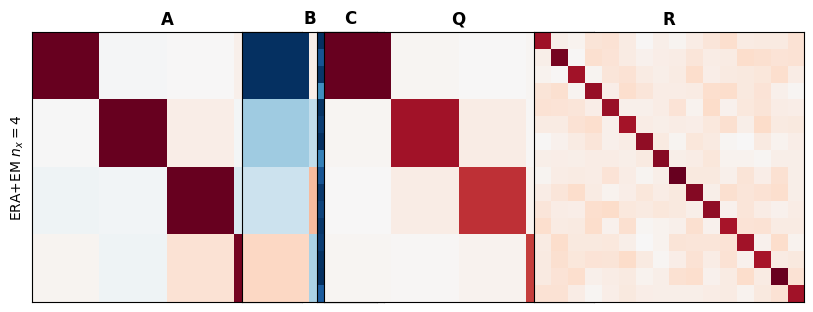

In [6]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_id_figure([ESTIMATES[CHOSEN_LATENT_DIM]], figsize=(8, 3))
plt.show()

In [7]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.10  # fraction of A4 content height (1 row)

configure_pgf()
fig = make_id_figure(
    [ESTIMATES[CHOSEN_LATENT_DIM]],
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "id.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/id.pgf


In [8]:
# ── caption ────────────────────────────────────────────────────────────────────
chosen = ESTIMATES[CHOSEN_LATENT_DIM]
n_x = CHOSEN_LATENT_DIM
n_y = chosen.C.shape[0]
n_u = chosen.B.shape[1]

caption = (
    rf"Identified system matrices for ERA+EM ($n_x = {n_x}$). "
    r"Red indicates positive, blue negative; colour scales are symmetric about zero."
)
save_caption(CAPTIONS_PATH / "id.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/id.tex
Identified system matrices for ERA+EM ($n_x = 4$). Red indicates positive, blue negative; colour scales are symmetric about zero.
